# Chapter 7 — Spectral Estimation

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch07_spectral_estimation.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch07_spectral_estimation.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch07_spectral_estimation.ipynb)

> **Motivating question.** The raw periodogram is noisy and unreliable — how do we get a spectrum we can trust?

## What this notebook demonstrates

- Why the periodogram is inconsistent (variance does not fall with N)
- Bartlett & Welch: averaging to cut variance (≈1/K)
- Multitaper (Slepian/DPSS) estimation
- Parametric AR spectra via Yule–Walker / Burg
- HRV band power (LF/HF) as a worked example

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | reduced (a lighter path runs in the browser) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from scipy.integrate import trapezoid
from scipy.signal import periodogram, welch, freqz
from scipy.signal.windows import dpss
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.pyplot as plt

CH = 7

BANDS = [("delta", 0.5, 4, bs.C['blue']),
         ("theta", 4, 8, bs.C['green']),
         ("alpha", 8, 11, bs.C['orange']),
         ("sigma", 11, 16, bs.C['purple']),
         ("beta", 16, 30, bs.C['red'])]
HRV_BANDS = [("VLF", 0.003, 0.04, bs.C['grey']),
             ("LF", 0.04, 0.15, bs.C['blue']),
             ("HF", 0.15, 0.40, bs.C['green'])]


def arburg(x, order):
    """Burg's method. Returns (a-coeffs length order, sigma2)."""
    x = np.asarray(x, float)
    x = x - x.mean()
    n = len(x)
    f = x.copy()
    b = x.copy()
    a = np.zeros(order)
    den = np.dot(f, f) + np.dot(b, b)
    E = np.dot(x, x) / n
    A = np.zeros(order + 1)
    A[0] = 1.0
    for m in range(order):
        num = -2.0 * np.dot(b[:n - m - 1], f[m + 1:])
        k = num / den if den != 0 else 0.0
        A_prev = A.copy()
        for i in range(1, m + 2):
            A[i] = A_prev[i] + k * A_prev[m + 1 - i]
        E *= (1 - k * k)
        f_new = f[m + 1:] + k * b[:n - m - 1]
        b_new = b[:n - m - 1] + k * f[m + 1:]
        f[m + 1:], b[:n - m - 1] = f_new, b_new
        den = (np.dot(f[m + 2:], f[m + 2:]) + np.dot(b[:n - m - 2], b[:n - m - 2])) \
            if (n - m - 2) > 0 else den
    a = -A[1:order + 1]
    return a, E


def ar_psd(a, sigma2, fs, nfft=1024):
    # Single tested implementation of the AR PSD (Appendix H); avoids a local copy
    # that could be re-broken into sigma2/|H|^2 (the reciprocal that inverts it).
    return bio.ar_psd(a, sigma2, fs, nfft)


def multitaper_psd(x, fs, NW=3.5, nfft=None):
    """Thomson multitaper PSD via DPSS (Slepian) tapers.

    Averages the ~2*NW-1 well-concentrated orthogonal tapered periodograms over
    the WHOLE record (no segmentation), trading a controllable half-bandwidth
    for variance reduction and low leakage.  Returns (freqs, one-sided PSD).
    """
    x = np.asarray(x, float)
    x = x - x.mean()
    n = len(x)
    if nfft is None:
        nfft = n
    K = max(1, int(round(2 * NW)) - 1)          # keep the well-concentrated tapers
    tapers = dpss(n, NW, K)                       # shape (K, n)
    psd = np.zeros(nfft // 2 + 1)
    for w in tapers:
        Xk = np.fft.rfft(w * x, n=nfft)
        psd += np.abs(Xk) ** 2
    psd /= K
    # one-sided normalization (unit-power DPSS tapers) -> PSD in units of x^2/Hz
    psd *= 2.0 / fs
    psd[0] /= 2.0
    if nfft % 2 == 0:
        psd[-1] /= 2.0
    f = np.fft.rfftfreq(nfft, d=1.0 / fs)
    return f, psd


def _ar_psd_onesided(x, order, fs, nfft=8192):
    """Correctly-normalized ONE-SIDED AR/Burg PSD on a uniform 0..fs/2 grid.

    Uses np.polyval on a uniform frequency grid (not freqz) so the peaks from
    near-unit-circle poles are captured and the PSD integrates to the signal
    variance: for white input the two-sided S = sigma2/|A|^2 integrates over
    the full circle to var(x); the one-sided version doubles that on 0..fs/2.
    """
    a, s2 = arburg(x, order)
    A = np.concatenate(([1.0], -a))            # A(z) = 1 - sum a_k z^-k
    f = np.linspace(0.0, fs / 2.0, nfft)
    Az = np.polyval(A[::-1], np.exp(-1j * 2 * np.pi * f / fs))
    psd = 2.0 * s2 / fs / np.abs(Az) ** 2      # one-sided PSD (units of x^2/Hz)
    return f, psd


def _bandpower_grid(f, psd, lo, hi):
    idx = (f >= lo) & (f < hi)
    return trapezoid(psd[idx], f[idx])

## 7.1  periodogram inconsistent

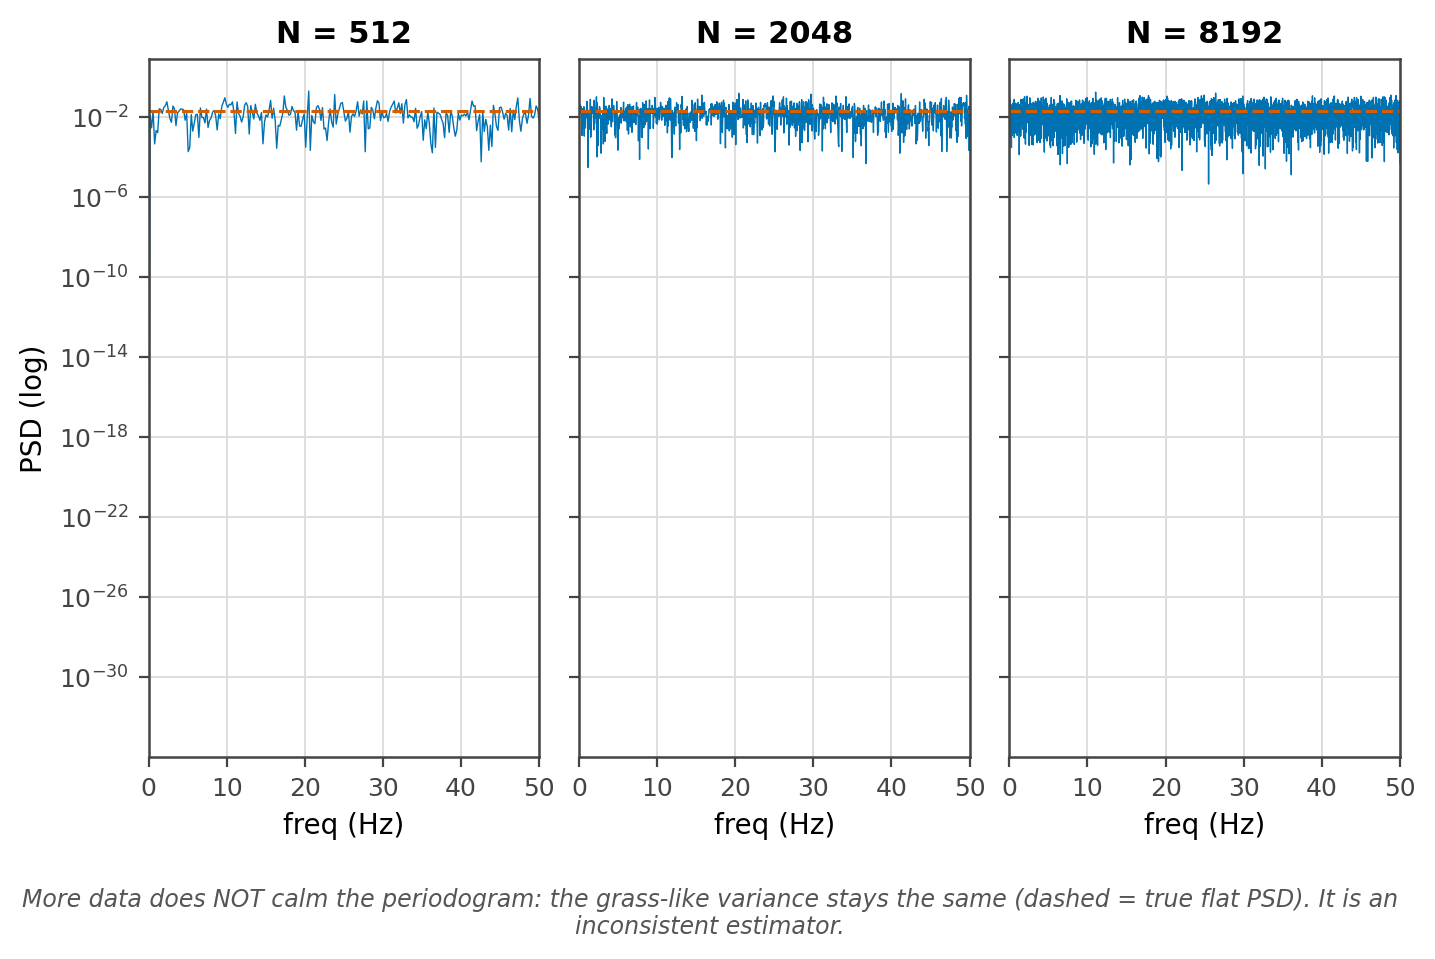

In [3]:
fs = 100.0
lengths = [512, 2048, 8192]
fig, axes = bs.newfig(w=7.2, h=4.4, nrows=1, ncols=3, sharey=True)
for ax, N in zip(axes, lengths):
    x = bio.white(N, seed=41)
    f, pxx = periodogram(x, fs=fs)
    ax.semilogy(f, pxx, color=bs.C['blue'], lw=0.5)
    # scipy periodogram is ONE-SIDED, so unit-variance white noise has mean 2/fs
    ax.axhline(2.0 / fs, color=bs.C['red'], ls='--', lw=1.1)
    ax.set_title(f"N = {N}")
    ax.set_xlabel("freq (Hz)")
    ax.set_xlim(0, fs / 2)
axes[0].set_ylabel("PSD (log)")
bs.takeaway(fig, "More data does NOT calm the periodogram: the grass-like "
                 "variance stays the same (dashed = true flat PSD). It is an "
                 "inconsistent estimator.")
plt.tight_layout()
plt.show()

## 7.2  welch variance

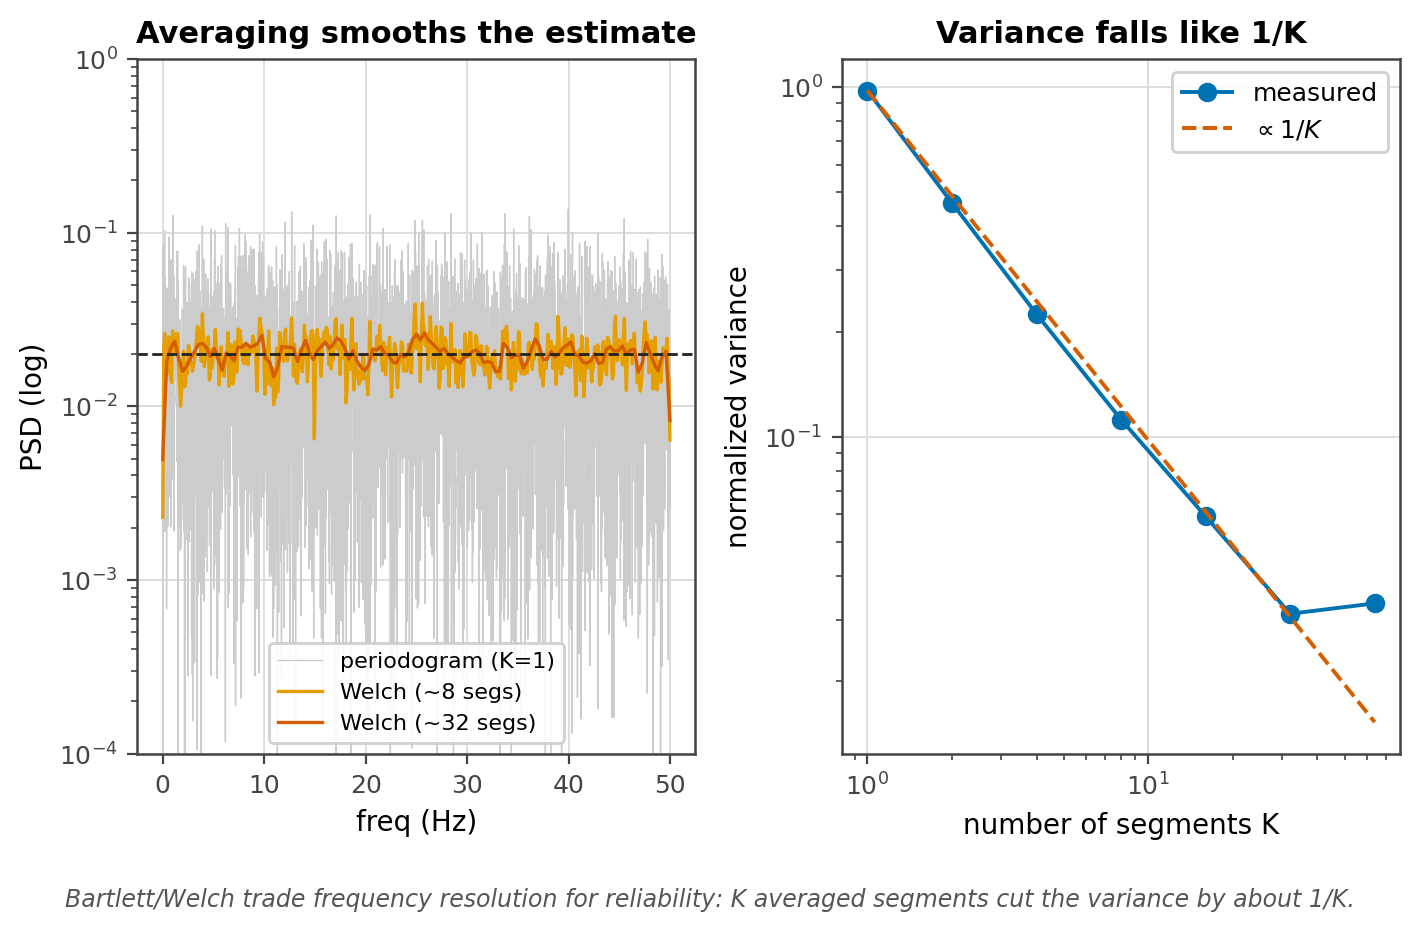

In [4]:
fs = 100.0
N = 8192
x = bio.white(N, seed=42)
f0, p0 = periodogram(x, fs=fs)

fig, axes = bs.newfig(w=7.2, h=4.4, nrows=1, ncols=2)
axes[0].semilogy(f0, p0, color=bs.C['lightgrey'], lw=0.5,
                 label="periodogram (K=1)")
for K, col in [(8, bs.C['orange']), (32, bs.C['red'])]:
    nperseg = N // K
    fw, pw = welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
    axes[0].semilogy(fw, pw, color=col, lw=1.2, label=f"Welch (~{K} segs)")
axes[0].axhline(2.0 / fs, color=bs.C['black'], ls='--', lw=1.0)  # one-sided true PSD = 2/fs
axes[0].set_ylim(1e-4, 1e0)   # clip: near-zero periodogram bins else squash the informative band
axes[0].set_title("Averaging smooths the estimate")
axes[0].set_xlabel("freq (Hz)"); axes[0].set_ylabel("PSD (log)")
axes[0].legend(loc="lower center", fontsize=8)

# Empirical: variance of the estimate vs number of segments K.
Ks = np.array([1, 2, 4, 8, 16, 32, 64])
var = []
for K in Ks:
    nperseg = max(N // K, 16)
    fw, pw = welch(x, fs=fs, nperseg=nperseg, noverlap=0, window='boxcar')
    var.append(np.var(pw / np.mean(pw)))
axes[1].loglog(Ks, var, 'o-', color=bs.C['blue'], label="measured")
axes[1].loglog(Ks, var[0] / Ks, '--', color=bs.C['red'], label=r"$\propto 1/K$")
axes[1].set_title("Variance falls like 1/K")
axes[1].set_xlabel("number of segments K")
axes[1].set_ylabel("normalized variance")
axes[1].legend()

bs.takeaway(fig, "Bartlett/Welch trade frequency resolution for reliability: "
                 "K averaged segments cut the variance by about 1/K.")
plt.tight_layout()
plt.show()

## 7.3  three estimators eeg

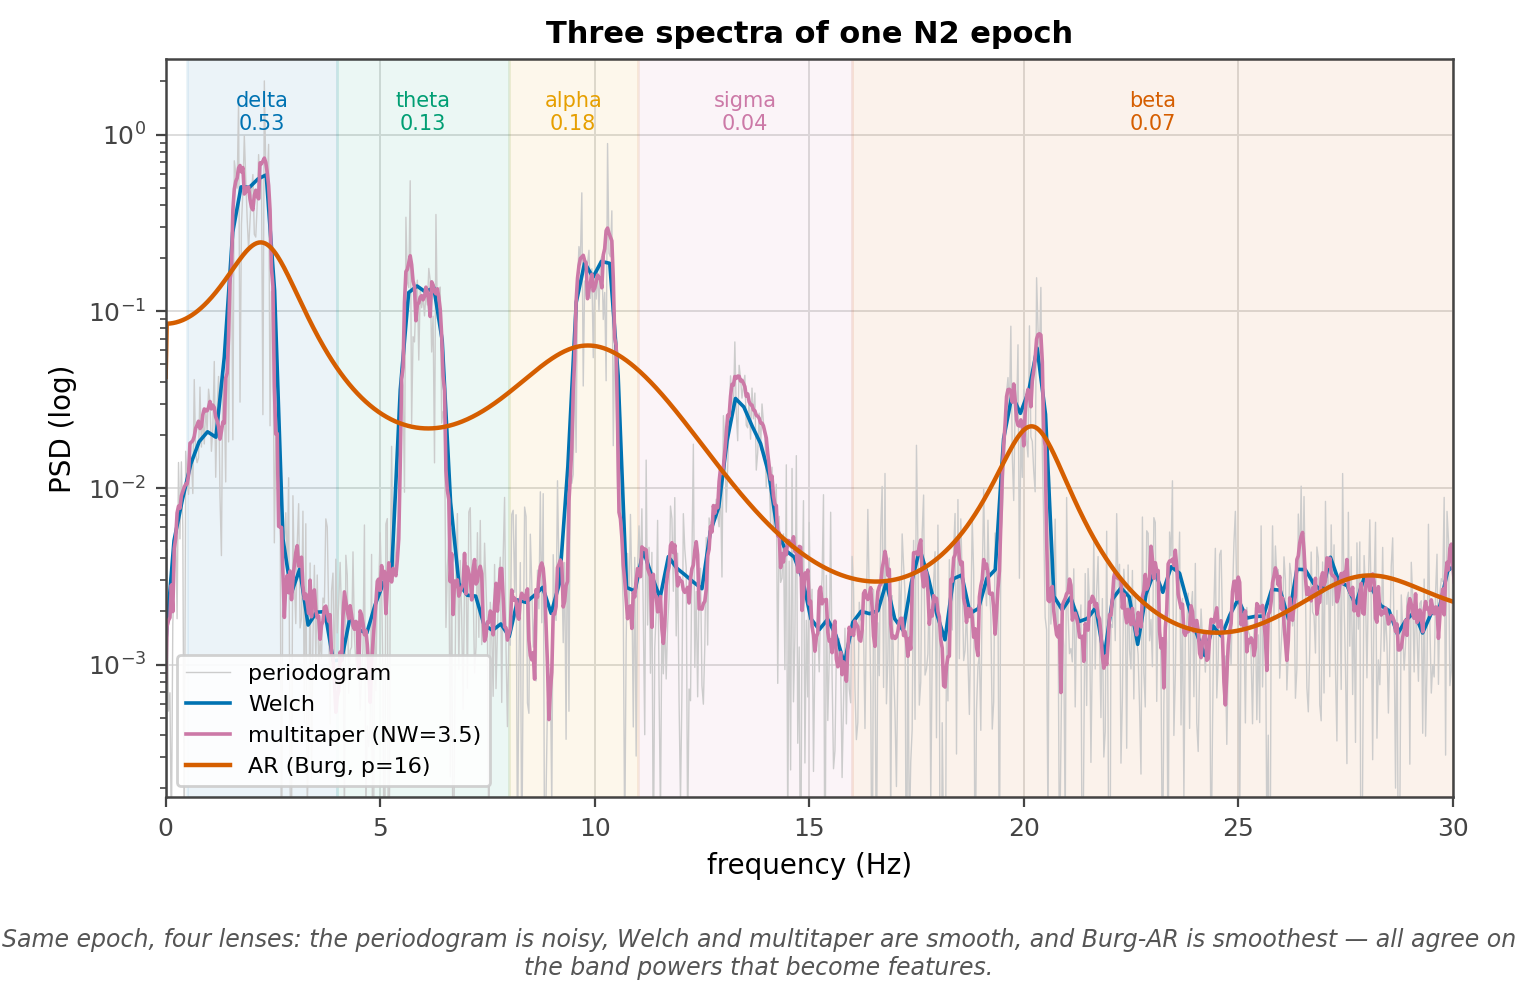

In [5]:
fs = 100.0
t, x = bio.eeg(duration=30.0, fs=fs, stage="N2")
x = x - x.mean()

f_pg, p_pg = periodogram(x, fs=fs)
f_we, p_we = welch(x, fs=fs, nperseg=512, noverlap=256)
f_mt, p_mt = multitaper_psd(x, fs, NW=3.5)         # DPSS / Slepian multitaper
a, s2 = arburg(x, 16)
f_ar, p_ar = ar_psd(a, s2, fs, nfft=2048)

fig, ax = bs.newfig(w=7.4, h=4.6)
ax.semilogy(f_pg, p_pg, color=bs.C['lightgrey'], lw=0.5,
            label="periodogram")
ax.semilogy(f_we, p_we, color=bs.C['blue'], lw=1.3, label="Welch")
ax.semilogy(f_mt, p_mt, color=bs.C['purple'], lw=1.3,
            label="multitaper (NW=3.5)")
ax.semilogy(f_ar, p_ar, color=bs.C['red'], lw=1.6, label="AR (Burg, p=16)")
ax.set_xlim(0, 30)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("PSD (log)")
ax.set_title("Three spectra of one N2 epoch")

# shade the clinical bands and annotate Welch-based band power
ymax = np.max(p_we) * 3
for name, lo, hi, col in BANDS:
    ax.axvspan(lo, hi, color=col, alpha=0.08)
    bp = bio.bandpower(x, fs, (lo, hi), nperseg=512)
    fc = (lo + hi) / 2
    ax.annotate(f"{name}\n{bp:.2f}", xy=(fc, ymax),
                ha="center", va="top", fontsize=7.5, color=col)
ax.set_ylim(ymax * 1e-4, ymax * 1.5)   # clip: a near-zero periodogram bin else squashes the plot
ax.legend(loc="lower left", fontsize=8)

bs.takeaway(fig, "Same epoch, four lenses: the periodogram is noisy, Welch "
                 "and multitaper are smooth, and Burg-AR is smoothest — all "
                 "agree on the band powers that become features.")
plt.tight_layout()
plt.show()

## 7.4  order sweep and diagram

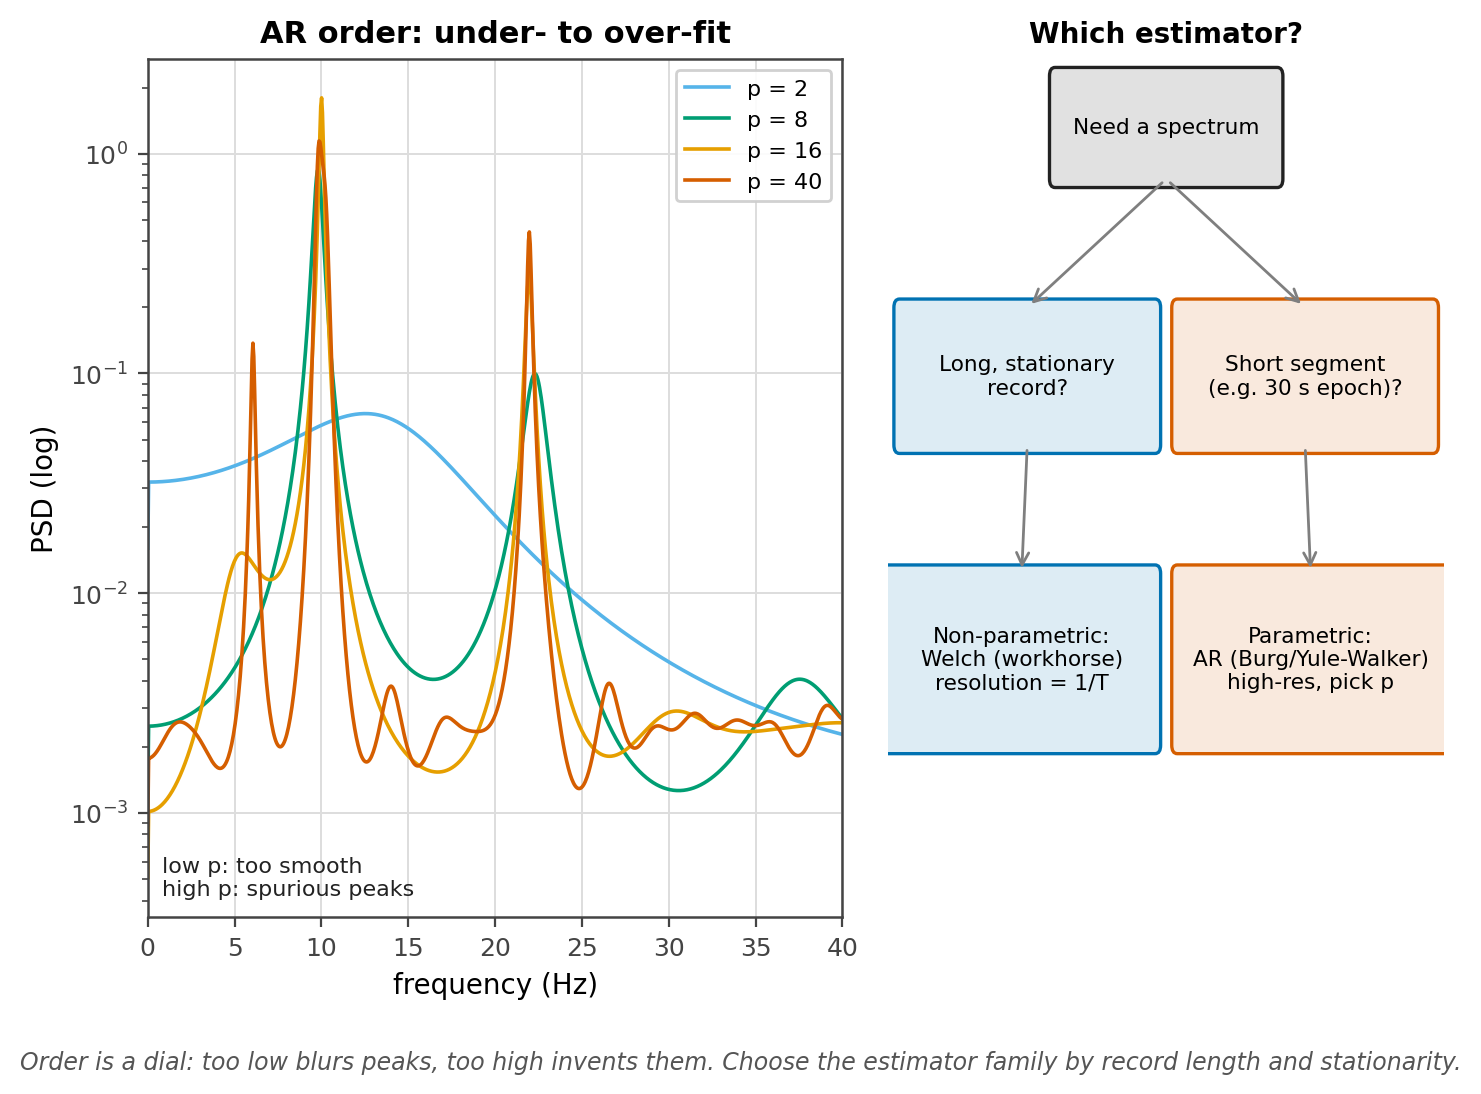

In [6]:
fs = 100.0
t, x = bio.eeg(duration=30.0, fs=fs, stage="W")   # clear alpha to resolve
x = x - x.mean()

fig, axes = bs.newfig(w=7.4, h=5.2, nrows=1, ncols=2,
                      gridspec_kw={'width_ratios': [1.25, 1]})

# ---- (a) order sweep ----
axA = axes[0]
for p, col in [(2, bs.C['sky']), (8, bs.C['green']),
               (16, bs.C['orange']), (40, bs.C['red'])]:
    a, s2 = arburg(x, p)
    f, psd = ar_psd(a, s2, fs, nfft=1024)
    axA.semilogy(f, psd, color=col, lw=1.3, label=f"p = {p}")
axA.set_xlim(0, 40)
axA.set_title("AR order: under- to over-fit")
axA.set_xlabel("frequency (Hz)"); axA.set_ylabel("PSD (log)")
axA.legend(fontsize=8)
axA.text(0.02, 0.02, "low p: too smooth\nhigh p: spurious peaks",
         transform=axA.transAxes, fontsize=8, va="bottom",
         color=bs.C['black'])

# ---- (b) decision diagram: non-parametric vs parametric ----
axB = axes[1]
axB.axis("off"); axB.grid(False)
axB.set_xlim(0, 1); axB.set_ylim(0, 1)

def box(x0, y0, w, h, text, color):
    p = FancyBboxPatch((x0, y0), w, h, boxstyle="round,pad=0.01",
                       linewidth=1.2, edgecolor=color, facecolor=color +
                       "22" if len(color) == 7 else color)
    axB.add_patch(p)
    axB.text(x0 + w / 2, y0 + h / 2, text, ha="center", va="center",
             fontsize=7.8, wrap=True)

def arrow(p0, p1):
    axB.add_patch(FancyArrowPatch(p0, p1, arrowstyle="->",
                                  mutation_scale=11, color=bs.C['grey']))

box(0.30, 0.86, 0.40, 0.12, "Need a spectrum", bs.C['black'])
box(0.02, 0.55, 0.46, 0.16, "Long, stationary\nrecord?", bs.C['blue'])
box(0.52, 0.55, 0.46, 0.16, "Short segment\n(e.g. 30 s epoch)?", bs.C['red'])
box(0.00, 0.20, 0.48, 0.20, "Non-parametric:\nWelch (workhorse)\nresolution = 1/T",
    bs.C['blue'])
box(0.52, 0.20, 0.48, 0.20, "Parametric:\nAR (Burg/Yule-Walker)\nhigh-res, pick p",
    bs.C['red'])
arrow((0.5, 0.86), (0.25, 0.71))
arrow((0.5, 0.86), (0.75, 0.71))
arrow((0.25, 0.55), (0.24, 0.40))
arrow((0.75, 0.55), (0.76, 0.40))
axB.set_title("Which estimator?", fontsize=10)

bs.takeaway(fig, "Order is a dial: too low blurs peaks, too high invents "
                 "them. Choose the estimator family by record length and "
                 "stationarity.")
plt.tight_layout()
plt.show()

## 7.5  hrv worked example

/var/folders/b8/tlcb8g7163zgtrljj8c2c9p80000gp/T/ipykernel_91292/2750991498.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


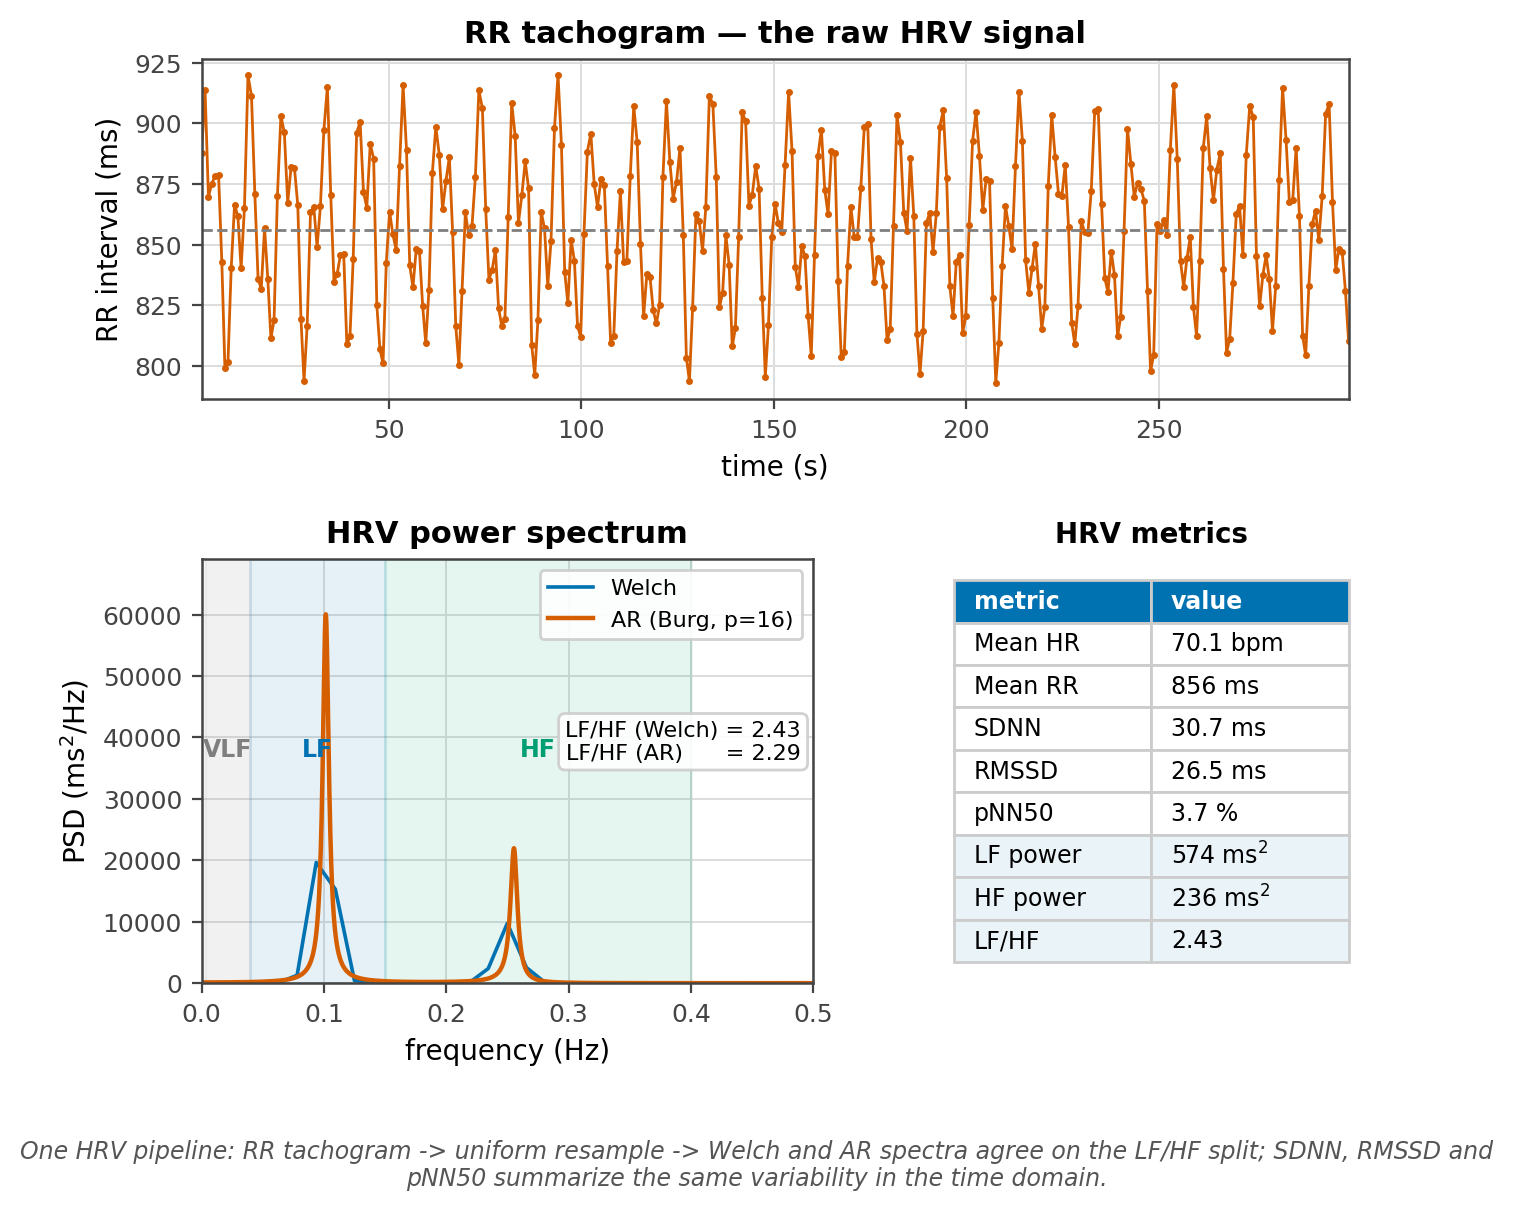

In [7]:
# ---- 1) RR tachogram from TRUE R-peak times ----
t, ecg, r_times = bio.ecg_hrv(duration=300, fs=250, seed=21)
rr = np.diff(r_times) * 1000.0          # RR intervals in ms
beat_t = r_times[1:]                     # each RR is timed at the 2nd beat

# ---- 2) time-domain HRV metrics (computed from rr) ----
mean_rr = np.mean(rr)
mean_hr = 60000.0 / mean_rr              # bpm
sdnn = np.std(rr, ddof=1)                # standard deviation of NN intervals
drr = np.diff(rr)
rmssd = np.sqrt(np.mean(drr ** 2))       # RMS of successive differences
pnn50 = 100.0 * np.sum(np.abs(drr) > 50.0) / len(drr)  # % of |ΔRR| > 50 ms

# ---- 3) resample the uneven RR series onto a uniform 4 Hz grid ----
fs_i = 4.0
ti = np.arange(beat_t[0], beat_t[-1], 1.0 / fs_i)
rr_i = np.interp(ti, beat_t, rr)         # linear interpolation to uniform grid
rr_i = rr_i - rr_i.mean()

# ---- 4) two spectral estimates: Welch and AR (Burg) ----
f_we, p_we = welch(rr_i, fs=fs_i, nperseg=256, noverlap=128, window='hann')
f_ar, p_ar = _ar_psd_onesided(rr_i, 16, fs_i, nfft=8192)

lf_w = _bandpower_grid(f_we, p_we, 0.04, 0.15)
hf_w = _bandpower_grid(f_we, p_we, 0.15, 0.40)
lf_a = _bandpower_grid(f_ar, p_ar, 0.04, 0.15)
hf_a = _bandpower_grid(f_ar, p_ar, 0.15, 0.40)

# ---- layout: tachogram (top), spectrum (bottom-left), metrics (bottom-right)
fig = plt.figure(figsize=(7.4, 6.0))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.25],
                      width_ratios=[1.55, 1.0], hspace=0.42, wspace=0.28)
axT = fig.add_subplot(gs[0, :])
axS = fig.add_subplot(gs[1, 0])
axM = fig.add_subplot(gs[1, 1])

# (a) RR tachogram
axT.plot(beat_t, rr, color=bs.C['red'], lw=1.0, marker='.', ms=3)
axT.axhline(mean_rr, color=bs.C['grey'], ls='--', lw=1.0)
axT.set_title("RR tachogram — the raw HRV signal")
axT.set_xlabel("time (s)")
axT.set_ylabel("RR interval (ms)")
axT.set_xlim(beat_t[0], beat_t[-1])

# (b) power spectrum: Welch vs AR, with VLF/LF/HF bands shaded
axS.plot(f_we, p_we, color=bs.C['blue'], lw=1.3, label="Welch")
axS.plot(f_ar, p_ar, color=bs.C['red'], lw=1.6, label="AR (Burg, p=16)")
ymax = max(np.max(p_we), np.max(p_ar[f_ar <= 0.4])) * 1.15
for name, lo, hi, col in HRV_BANDS:
    axS.axvspan(lo, hi, color=col, alpha=0.10)
    axS.text((lo + hi) / 2, ymax * 0.55, name, ha="center", va="center",
             fontsize=8.5, color=col, fontweight="bold")
axS.set_xlim(0, 0.5)
axS.set_ylim(0, ymax)
axS.set_title("HRV power spectrum")
axS.set_xlabel("frequency (Hz)")
axS.set_ylabel(r"PSD (ms$^2$/Hz)")
axS.legend(loc="upper right", fontsize=8)
axS.text(0.98, 0.62,
         f"LF/HF (Welch) = {lf_w / hf_w:.2f}\nLF/HF (AR)      = {lf_a / hf_a:.2f}",
         transform=axS.transAxes, va="top", ha="right", fontsize=8,
         bbox=dict(boxstyle="round,pad=0.3", fc="white",
                   ec=bs.C['lightgrey'], alpha=0.9))

# (c) time-domain + frequency-domain metrics table
axM.axis("off")
rows = [
    ("Mean HR", f"{mean_hr:.1f} bpm"),
    ("Mean RR", f"{mean_rr:.0f} ms"),
    ("SDNN", f"{sdnn:.1f} ms"),
    ("RMSSD", f"{rmssd:.1f} ms"),
    ("pNN50", f"{pnn50:.1f} %"),
    ("LF power", f"{lf_w:.0f} ms$^2$"),
    ("HF power", f"{hf_w:.0f} ms$^2$"),
    ("LF/HF", f"{lf_w / hf_w:.2f}"),
]
tbl = axM.table(cellText=rows, colLabels=["metric", "value"],
                cellLoc="left", colLoc="left", loc="center",
                bbox=[0.0, 0.05, 1.0, 0.9])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
for (r_, c_), cell in tbl.get_celld().items():
    cell.set_edgecolor(bs.C['lightgrey'])
    if r_ == 0:
        cell.set_facecolor(bs.C['blue'])
        cell.set_text_props(color="white", fontweight="bold")
    elif r_ >= 6:                       # frequency-domain rows shaded
        cell.set_facecolor("#EAF3F8")
axM.set_title("HRV metrics", fontsize=10)

bs.takeaway(fig, "One HRV pipeline: RR tachogram -> uniform resample -> "
                 "Welch and AR spectra agree on the LF/HF split; SDNN, RMSSD "
                 "and pNN50 summarize the same variability in the time domain.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above and the numbers below *exactly* — the cell below **asserts** them with `expect_close`, so a broken environment is flagged rather than failing silently.

In [8]:
from bsp.metrics import (alias_frequency, quantization_snr_db, sqrtN_gain_db,
                         snr_db, cohens_kappa, macro_f1)
from bsp.notebook_checks import expect_close, expected_output_table
from IPython.display import Markdown, display
from scipy.signal import welch as _welch
_x = np.sin(2*np.pi*10*np.arange(1000)/100)
_f, _p = _welch(_x, fs=100, nperseg=256)
_rows = []
_rows.append(expect_close('Welch peak of a 10 Hz tone (Hz)', float(_f[np.argmax(_p)]), 10.0, 0.6, 'abs'))
display(Markdown(expected_output_table(_rows)))

[PASS] Welch peak of a 10 Hz tone (Hz): got 10.16, expected 10 (abs)


| Quantity | Got | Expected | Status |
|---|---:|---:|:--:|
| Welch peak of a 10 Hz tone (Hz) | 10.16 | 10 | ✅ |

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `pwelch`, `pmtm` (multitaper), `pburg`, `pyulear`.

## Sweep and defend — the resolution ↔ variance trade-off

There is **no single best Welch setting**. More, shorter segments (larger *K*) cut the *variance* of the estimate but coarsen the *frequency resolution*; fewer, longer segments do the reverse. The cell below **measures** both effects as you sweep *K*, so you can see the trade-off rather than take it on faith.

**Spec to design against:** on a 30 s epoch you must resolve a **spindle peak near 13 Hz that sits ~2 Hz from the alpha edge**, and you need the estimate stable enough that the peak is not lost in the grass.

**Defend it (write your answer in the workspace):** (1) which *K* does your spec pick, and why — tie it to the 2 Hz separation *and* the variance? (2) what *K* would you switch to if the epoch were only **5 s** instead of 30 s? (3) name one estimator from this chapter you would reach for *instead* of Welch here, and the spec change that would make it the better choice.

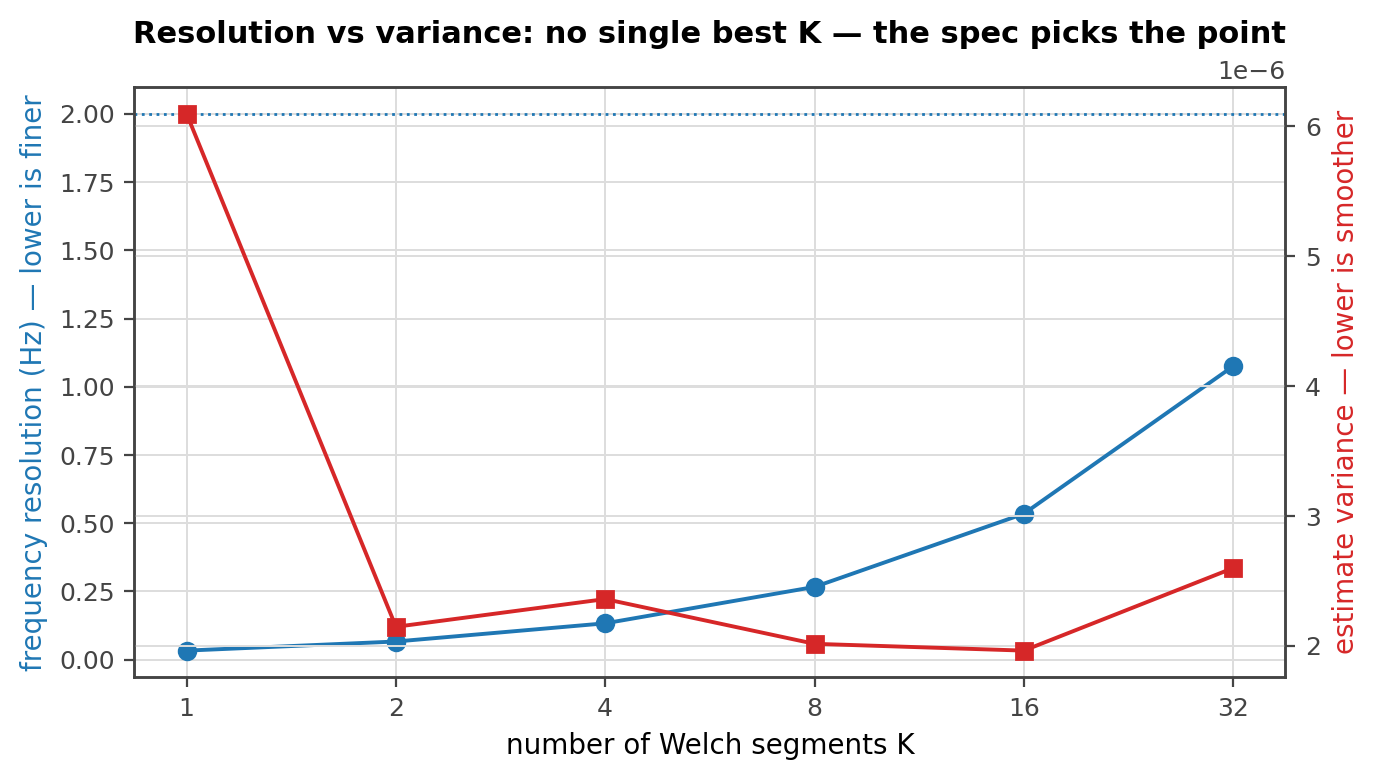

Finer than the 2 Hz spec line (dotted) needs small K; a stable estimate needs large K.
resolution (Hz): [0.03, 0.07, 0.13, 0.27, 0.53, 1.08]
variance      : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [9]:
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import welch
fs, N, rng = 100.0, 3000, np.random.default_rng(7)
Ks = [1, 2, 4, 8, 16, 32]
res, var = [], []
for K in Ks:
    nper = N // K
    res.append(fs / nper)                       # frequency resolution (Hz), lower = finer
    ests = []
    for _ in range(40):                         # 40 independent records -> measure variance
        f, p = welch(rng.standard_normal(N), fs=fs, nperseg=nper, noverlap=nper//2)
        ests.append(p[(f >= 10) & (f <= 16)].mean())
    var.append(float(np.var(ests)))
fig, axL = plt.subplots(figsize=(7, 4))
axL.plot(Ks, res, 'o-', color='tab:blue', label='resolution (Hz)')
axL.set_xlabel('number of Welch segments K'); axL.set_xscale('log', base=2)
axL.set_xticks(Ks); axL.set_xticklabels(Ks)
axL.set_ylabel('frequency resolution (Hz) — lower is finer', color='tab:blue')
axL.axhline(2.0, color='tab:blue', ls=':', lw=1)   # the 2 Hz spec line
axR = axL.twinx()
axR.plot(Ks, var, 's-', color='tab:red', label='estimate variance')
axR.set_ylabel('estimate variance — lower is smoother', color='tab:red')
plt.title('Resolution vs variance: no single best K — the spec picks the point')
plt.tight_layout(); plt.show()
print('Finer than the 2 Hz spec line (dotted) needs small K; a stable estimate needs large K.')
print('resolution (Hz):', [round(r, 2) for r in res])
print('variance      :', [round(v, 4) for v in var])

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Watch the periodogram's variance NOT shrink as the record lengthens.

<details><summary>💡 Hint &amp; what you should see</summary>

The raw periodogram is **inconsistent**: more samples give finer Δf but the per-bin variance stays ~constant (spiky). Only **averaging** (Welch, ≈1/K) cuts variance.

</details>

**2.** Compare Welch, multitaper and AR-Burg on the same EEG epoch.

<details><summary>💡 Hint &amp; what you should see</summary>

Welch and multitaper trade variance for resolution (smoother, broader peaks); AR-Burg gives sharp peaks but can **hallucinate** them at the wrong order. The 10 Hz alpha peak should land near 10 Hz in all three.

</details>

In [10]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch07_figures.py`.*